# Real World Classification

## Load data

Import the necessary libraries

In [ ]:
# If you do not use colab. You should install these packages.
# !pip install numpy
# !pip install pandas
# !pip install matplotlib
# !pip install scikit-learn
# !pip install graphviz

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

seed=40
np.random.seed(seed)

load the data

In [13]:
import pandas as pd

# load data
df = pd.read_csv('data/NYCU_Iris.csv')

# vyber numerické sloupce
numeric_df = df.select_dtypes(include=['number'])

# výpočty
median_values = numeric_df.median()
std_values = numeric_df.std()

# filtr: jen nenulové hodnoty
median_nonzero = median_values[median_values != 0]
std_nonzero = std_values[std_values != 0]

# výpis median
print("Median:")
for col, val in median_nonzero.items():
    print(f"{col}: {val}")

# výpis std
print("\nStandard deviation:")
for col, val in std_nonzero.items():
    print(f"{col}: {val}")

Median:
Id: 250.5
SepalLengthCm: 6.3
SepalWidthCm: 2.9
PetalLengthCm: 5.085611510791367
PetalWidthCm: 1.6
BranchLength: 16.3
AvgDust: 44.0
SepalLengthMajorAxis: 6.316421934120221
SepalLengthMinorAxis: 6.31031544209928
SepalLengthElongation: 6.320980451891499
SepalLengthCompactness: 6.332139265692754
SepalLengthSpread: 6.319995961681744
SepalLengthCurvature: 6.324463539348475
SepalWidthMajorAxis: 2.83127124781612
SepalWidthMinorAxis: 2.8411318987323253
SepalWidthElongation: 2.835939574033791
SepalWidthCompactness: 2.8431686241868595
SepalWidthSpread: 2.8393511261528768
SepalWidthCurvature: 2.8340628464577584
PetalLengthMajorAxis: 5.023524507051234
PetalLengthMinorAxis: 5.034102104875855
PetalLengthElongation: 5.028692632832937
PetalLengthCompactness: 5.025172446308207
PetalLengthSpread: 5.022804169495634
PetalLengthCurvature: 5.0356848747775125
PetalWidthMajorAxis: 1.673776658517833
PetalWidthMinorAxis: 1.6777021433614974
PetalWidthElongation: 1.6760034520745213
PetalWidthCompactness: 1

## Data Preprocessing

In [17]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder
from sklearn.impute import KNNImputer

def data_preprocessing(df):
    # transform label to bi-class
    df['Species'] = df['Species'].astype(str).str.strip()
    le = LabelEncoder()
    df['Species'] = le.fit_transform(df['Species'])

    feature_cols = [c for c in df.columns if c not in ['Id', 'Species']]

    # transform string to number
    for col in feature_cols:
        df[col] = pd.to_numeric(df[col], errors='coerce')

    # find columns with missing values
    cols_with_missing = df[feature_cols].columns[df[feature_cols].isnull().any()]

    print("Columns with missing values:")
    print(list(cols_with_missing))

    # ---------- BEFORE ----------
    print("\nBEFORE imputation:")

    print("\nMedian:")
    for col in cols_with_missing:
        print(f"{col}: {df[col].median()}")

    print("\nStandard deviation:")
    for col in cols_with_missing:
        print(f"{col}: {df[col].std()}")

    # ---------- KNN IMPUTATION ----------
    imputer = KNNImputer(n_neighbors=5)
    df[feature_cols] = imputer.fit_transform(df[feature_cols])
    # -----------------------------------

    # ---------- AFTER ----------
    print("\nAFTER imputation:")

    print("\nMedian:")
    for col in cols_with_missing:
        print(f"{col}: {df[col].median()}")

    print("\nStandard deviation:")
    for col in cols_with_missing:
        print(f"{col}: {df[col].std()}")

    return df, feature_cols


# load dataset
df = pd.read_csv('data/NYCU_Iris.csv')

# run preprocessing
df, feature_cols = data_preprocessing(df)

Columns with missing values:
['SepalLengthCm', 'SepalWidthCm', 'PetalLengthCm', 'PetalWidthCm', 'BranchLength']

BEFORE imputation:

Median:
SepalLengthCm: 6.3
SepalWidthCm: 2.9
PetalLengthCm: 5.085611510791367
PetalWidthCm: 1.6
BranchLength: 16.3

Standard deviation:
SepalLengthCm: 1.0371145018646923
SepalWidthCm: 0.38956399923008017
PetalLengthCm: 1.5828073840563788
PetalWidthCm: 0.706689351902183
BranchLength: 1.0352277983261677

AFTER imputation:

Median:
SepalLengthCm: 6.3
SepalWidthCm: 2.9
PetalLengthCm: 5.03568345323741
PetalWidthCm: 1.7
BranchLength: 16.3

Standard deviation:
SepalLengthCm: 1.009274811778924
SepalWidthCm: 0.37243395723941447
PetalLengthCm: 1.514954874934102
PetalWidthCm: 0.6946450531744969
BranchLength: 1.0110123928602626


In [5]:
df.describe()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,BranchLength,AvgDust,SepalLengthMajorAxis,SepalLengthMinorAxis,SepalLengthElongation,...,LeafHueVariation,CanopyLightCapture,CanopyMoistureSignal,SoilMoistureSignal,AmbientHumiditySignal,ThermalResponseIndex,UVExposureIndex,WindStressIndex,GrowthVigorIndex,Species
count,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,...,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.0000
mean,250.500000,6.319840,2.837040,5.049883,1.684440,16.303440,46.745800,6.316422,6.323365,6.320980,...,0.068882,-0.029672,-0.015074,0.037059,0.082579,0.011686,0.077167,-0.034112,0.029674,0.5200
std,144.481833,1.009275,0.372434,1.514955,0.694645,1.011012,30.032428,1.009859,1.043500,1.024075,...,1.049557,1.046532,1.024190,0.995562,1.033822,1.011917,0.969005,0.949463,0.969047,0.5001
min,1.000000,3.000000,1.500000,0.500000,-1.000000,12.700000,0.600000,2.877573,2.944078,2.955459,...,-3.258345,-3.090824,-2.673773,-2.735569,-3.033392,-2.625754,-3.143116,-2.878216,-2.589544,0.0000
25%,125.750000,5.800000,2.630000,4.500000,1.300000,15.800000,18.500000,5.836615,5.801651,5.793089,...,-0.625022,-0.702388,-0.649046,-0.630572,-0.627218,-0.718793,-0.529432,-0.649448,-0.653394,0.0000
50%,250.500000,6.300000,2.900000,5.035683,1.700000,16.300000,44.000000,6.316422,6.310315,6.320980,...,0.076748,-0.047413,-0.044223,-0.022831,0.109614,-0.017135,0.112847,-0.019524,0.044542,1.0000
75%,375.250000,6.700000,3.040000,5.300000,2.000000,16.700000,73.200000,6.738205,6.797044,6.699885,...,0.806166,0.655584,0.641842,0.750853,0.816614,0.743847,0.751684,0.631034,0.674469,1.0000
max,500.000000,9.600000,4.000000,9.200000,4.300000,19.700000,98.700000,10.032204,10.146460,10.262641,...,3.333114,3.888629,3.174867,3.109433,3.507325,3.100138,2.626066,2.515151,3.254291,1.0000


## Data Exploration

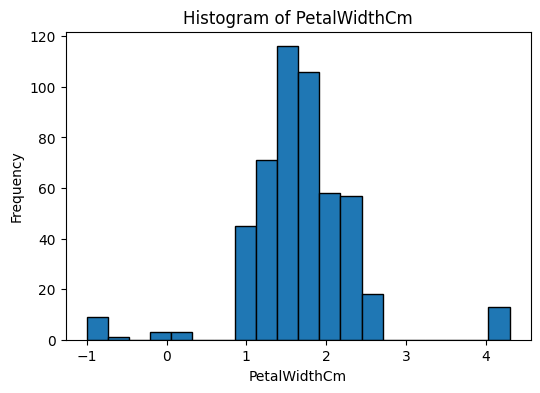

Feature with highest positive correlation:
PetalWidthCompactness: 0.9916701901370253

Top 5 features with strongest negative correlations:
SepalWidthMajorAxis: -0.09635042983649401
SepalGlossIndex: -0.09520000072196652
SepalWidthCompactness: -0.0884963955916379
SepalWidthCurvature: -0.0813343822833098
SepalWidthMinorAxis: -0.07439241023821906


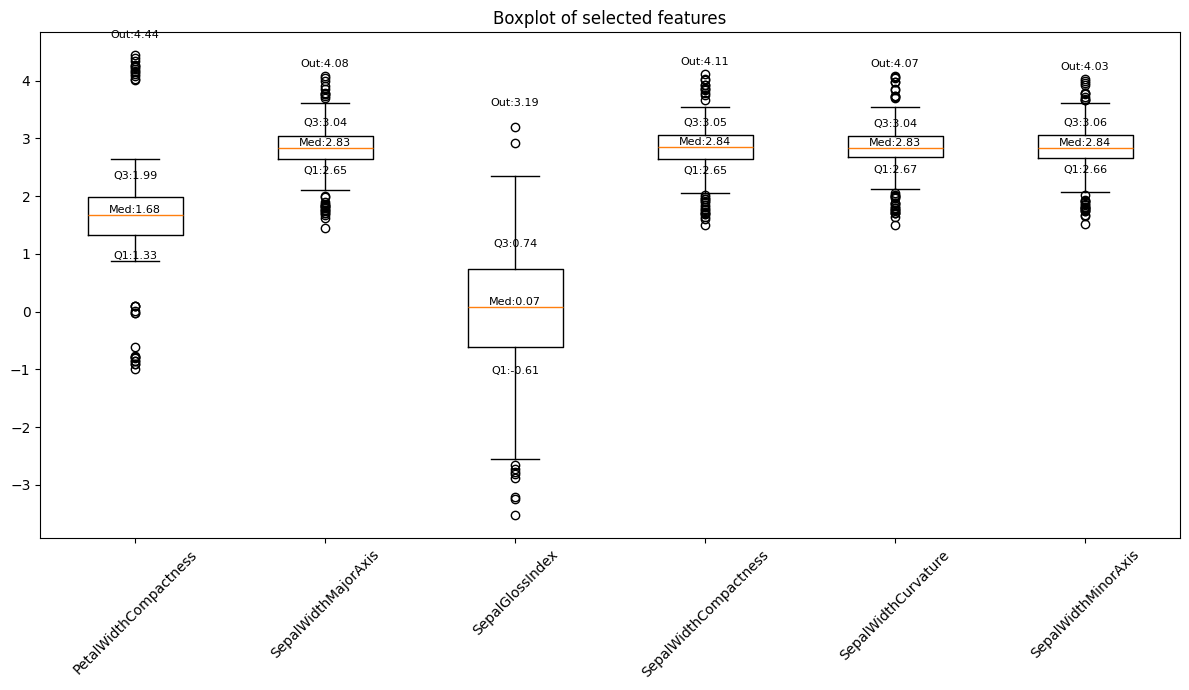

In [23]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from sklearn.feature_selection import r_regression

# ---------- 4(a) Histogram ----------
data = df['PetalWidthCm'].dropna()

plt.figure(figsize=(6,4))

# histogram pouze s okraji
plt.hist(data, bins=20, edgecolor='black')

plt.title('Histogram of PetalWidthCm')
plt.xlabel('PetalWidthCm')
plt.ylabel('Frequency')
plt.show()

# ---------- 4(b) Pearson correlation ----------
exclude_cols = ['PetalWidthCm', 'Species', 'Id']
features = [col for col in df.columns if col not in exclude_cols]

X = df[features]
y = df['PetalWidthCm']

corr_values = r_regression(X, y)

corr_df = pd.DataFrame({
    'Feature': features,
    'Correlation': corr_values
})

top_positive = corr_df.sort_values(by='Correlation', ascending=False).iloc[0]

print("Feature with highest positive correlation:")
print(f"{top_positive['Feature']}: {top_positive['Correlation']}")

# ---------- 4(c) Top 5 negative correlations ----------
top_negative = corr_df.sort_values(by='Correlation').head(5)

print("\nTop 5 features with strongest negative correlations:")
for _, row in top_negative.iterrows():
    print(f"{row['Feature']}: {row['Correlation']}")

# ---------- 4(d) Boxplot ----------
selected_features = [top_positive['Feature']] + list(top_negative['Feature'])

plt.figure(figsize=(12,7))  # větší prostor
box_data = [df[col].dropna() for col in selected_features]

plt.boxplot(box_data, labels=selected_features)

# přidání hodnot s offsetem (aby se nepřekrývaly)
for i, col in enumerate(selected_features):
    d = df[col].dropna()
    med = np.median(d)
    q1 = np.percentile(d, 25)
    q3 = np.percentile(d, 75)

    iqr = q3 - q1
    lb = q1 - 1.5 * iqr
    ub = q3 + 1.5 * iqr
    outs = d[(d < lb) | (d > ub)]
    max_out = outs.max() if len(outs) > 0 else None

    x = i + 1

    # větší vertikální odsazení
    plt.text(x, med, f'Med:{med:.2f}', ha='center', va='bottom', fontsize=8)
    plt.text(x, q1 - 0.05*(max(d)-min(d)), f'Q1:{q1:.2f}', ha='center', va='top', fontsize=8)
    plt.text(x, q3 + 0.05*(max(d)-min(d)), f'Q3:{q3:.2f}', ha='center', va='bottom', fontsize=8)

    if max_out is not None:
        plt.text(x, max_out + 0.05*(max(d)-min(d)), f'Out:{max_out:.2f}', ha='center', va='bottom', fontsize=8)

plt.title("Boxplot of selected features")
plt.xticks(rotation=45)
plt.tight_layout()  # lepší spacing
plt.show()

## Model Training

### Prepare the data

In [62]:
# Split the data into training and testing sets
from sklearn.model_selection import train_test_split


# normalize the data to [0,1]
for col in feature_cols:
    col_min = df[col].min()
    col_max = df[col].max()
    if col_max > col_min:
        df[col] = (df[col] - col_min) / (col_max - col_min)
    else:
        df[col] = 0.0
        
X = df[feature_cols].values.astype(float)
y = df['Species'].values
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=seed)

df.head()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,BranchLength,AvgDust,SepalLengthMajorAxis,SepalLengthMinorAxis,SepalLengthElongation,SepalLengthCompactness,SepalLengthSpread,SepalLengthCurvature,SepalWidthMajorAxis,SepalWidthMinorAxis,SepalWidthElongation,SepalWidthCompactness,SepalWidthSpread,SepalWidthCurvature,PetalLengthMajorAxis,PetalLengthMinorAxis,PetalLengthElongation,PetalLengthCompactness,PetalLengthSpread,PetalLengthCurvature,PetalWidthMajorAxis,PetalWidthMinorAxis,PetalWidthElongation,PetalWidthCompactness,PetalWidthSpread,PetalWidthCurvature,IrisPigmentDensity,IrisPigmentUniformity,IrisPigmentContrast,IrisPigmentGranularity,IrisVenationDensity,IrisVenationDepth,IrisVenationSharpness,IrisVenationAsymmetry,FloralSymmetryScore,FloralCompactnessScore,FloralSpreadScore,FloralSlendernessScore,BloomMaturityIndex,BloomFreshnessIndex,BloomHydrationIndex,BloomRigidityIndex,SepalTextureIndex,SepalGlossIndex,SepalThicknessIndex,SepalEdgeSmoothness,PetalTextureIndex,PetalGlossIndex,PetalThicknessIndex,PetalEdgeSmoothness,AntherVisibilityIndex,StigmaProminenceIndex,PollenResidueIndex,NectarExposureIndex,StemStabilityIndex,StemFlexibilityIndex,LeafShadowIndex,LeafHueVariation,CanopyLightCapture,CanopyMoistureSignal,SoilMoistureSignal,AmbientHumiditySignal,ThermalResponseIndex,UVExposureIndex,WindStressIndex,GrowthVigorIndex,Species
0,1,0.606061,0.608,0.482759,0.452830,0.600000,0.376147,0.544026,0.529185,0.548614,0.582692,0.572504,0.530047,0.527133,0.527696,0.536507,0.514932,0.513644,0.519139,0.441004,0.463109,0.483343,0.453996,0.495130,0.479248,0.428886,0.430426,0.446776,0.442350,0.432628,0.459504,0.576988,0.592334,0.610968,0.590791,0.448160,0.589738,0.412834,0.424483,0.348740,0.384501,0.591312,0.640594,0.788231,0.581634,0.791919,0.539621,1.000000,0.486081,0.211179,0.419144,0.375791,0.548061,0.515410,0.576121,0.655839,0.622563,0.653989,0.557894,0.717014,0.593884,0.443144,0.565095,0.580677,0.449986,0.027756,0.419409,0.693758,0.602718,0.589990,0.217516,0
1,2,0.515152,0.680,0.459770,0.471698,0.528571,0.963303,0.464754,0.442295,0.444221,0.512537,0.559856,0.536415,0.656229,0.668987,0.657377,0.660303,0.621135,0.627644,0.448097,0.449914,0.432501,0.422424,0.438494,0.437162,0.448801,0.459660,0.455990,0.458712,0.444494,0.474087,0.411757,0.420955,0.632056,0.524727,0.606123,0.487151,0.616674,0.519863,0.423266,0.237170,0.496306,0.092653,0.391857,0.485662,0.116700,0.550328,0.706520,0.383510,0.350663,0.275818,0.338973,0.497322,0.332720,0.397530,0.375183,0.641278,0.762475,0.598152,0.420179,0.321467,0.370503,0.301642,0.626733,0.259595,0.417482,0.568359,0.384086,0.564410,0.823373,0.459439,0
2,3,0.590909,0.616,0.505747,0.471698,0.600000,0.740061,0.537937,0.530229,0.524031,0.589459,0.574458,0.594904,0.527133,0.527696,0.536507,0.514932,0.513644,0.519139,0.467387,0.471787,0.473393,0.503385,0.459082,0.505354,0.441833,0.449074,0.466332,0.447658,0.452507,0.454340,0.668919,0.575578,0.538429,0.416474,0.577985,0.387585,0.422835,0.443992,0.729694,0.644108,0.462684,0.630234,0.583238,0.387579,0.132535,0.352645,0.594465,0.618218,0.500258,0.656400,0.448974,0.440351,0.608603,0.227284,0.467332,0.699177,0.405760,0.333450,0.480573,0.304979,0.424631,0.579598,0.620325,0.516296,0.668622,0.512741,0.360130,0.282303,0.500461,0.344289,0
3,4,0.378788,0.320,0.527082,0.433962,0.414286,0.604485,0.381672,0.358911,0.332111,0.381245,0.370149,0.374759,0.312087,0.362065,0.347946,0.314495,0.296704,0.314060,0.495542,0.492686,0.500118,0.500035,0.497344,0.496205,0.411380,0.413197,0.412820,0.430499,0.424219,0.420895,0.378203,0.680117,0.600110,0.702070,0.450493,0.662930,0.454233,0.439374,0.384085,0.604914,0.236733,0.626302,0.602259,0.474412,0.193615,0.467129,0.397502,0.684380,0.759370,0.445596,0.508893,0.536098,0.466366,0.345855,0.315127,0.608086,0.805612,0.256201,0.455345,0.205758,0.449260,0.469160,0.573916,0.671291,0.416456,0.392474,0.323568,0.407208,0.623292,0.650231,0
4,5,0.530303,0.520,0.471264,0.471698,0.528571,0.152905,0.478459,0.485877,0.454197,0.496096,0.480665,0.4654

### Train the model!

50. Training loss: 0.640681989845087, Val loss:0.694416421029334
100. Training loss: 0.6081167150202147, Val loss:0.6839444625329307
150. Training loss: 0.582462079002668, Val loss:0.6782679356019601
200. Training loss: 0.5618233234814827, Val loss:0.6758969521361576
250. Training loss: 0.5448892735765808, Val loss:0.6758379176551061
300. Training loss: 0.5307471737383754, Val loss:0.6774169097788035
350. Training loss: 0.5187522915605816, Val loss:0.6801673912607624
400. Training loss: 0.5084407478648576, Val loss:0.6837598771696833
450. Training loss: 0.4994722051980582, Val loss:0.6879574834750036
500. Training loss: 0.491592139248158, Val loss:0.6925872888277969
550. Training loss: 0.48460673945308486, Val loss:0.6975214601260517
600. Training loss: 0.47836595674912125, Val loss:0.7026645247325802
650. Training loss: 0.4727518554098428, Val loss:0.7079446011044122
700. Training loss: 0.4676704658248252, Val loss:0.7133072382436569
750. Training loss: 0.4630459852678921, Val loss:0.

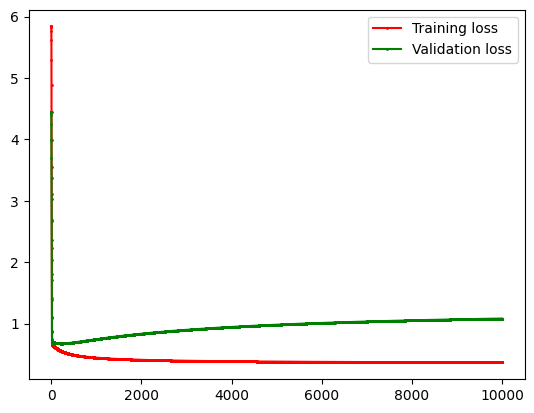

Model parameters (weights): [[-3.5474497 ]
 [ 0.73971279]
 [-0.39254606]
 [-1.21737756]
 [ 2.84002946]
 [-0.4887788 ]
 [ 0.16588373]
 [ 0.236751  ]
 [-0.09378417]
 [ 1.16947139]
 [ 0.5115986 ]
 [ 0.08752643]
 [ 1.14047196]
 [ 0.35936167]
 [-1.62608173]
 [ 0.58471007]
 [ 0.9647545 ]
 [ 1.09528451]
 [ 0.00973626]
 [ 0.50964324]
 [ 0.690161  ]
 [ 0.15755787]
 [-0.22727797]
 [ 0.07020596]
 [-0.20041825]
 [ 3.09654433]
 [ 2.79437427]
 [ 3.17701571]
 [ 2.68714502]
 [ 2.45086008]
 [ 2.78193008]
 [-2.17003371]
 [ 1.75301318]
 [-1.5105368 ]
 [-1.99903518]
 [-0.84869984]
 [-1.37290097]
 [-0.52937087]
 [-0.3296478 ]
 [-1.58411998]
 [ 0.88229385]
 [-0.09891041]
 [-0.90701191]
 [ 0.81517322]
 [-0.169775  ]
 [-0.89316093]
 [ 0.07589956]
 [ 0.21816081]
 [-3.05532903]
 [ 0.15648866]
 [-1.0515321 ]
 [ 0.40323227]
 [ 0.56559622]
 [ 0.27006407]
 [-0.65692894]
 [ 0.60521424]
 [-1.75527689]
 [-1.58957175]
 [-0.81881602]
 [ 0.51648973]
 [ 0.18058133]
 [-0.44090459]
 [-0.09480573]
 [-1.18015242]
 [ 0.7103297

In [74]:
# Use the LinearModel to fit the data

from model.linear_model import LinearModel
from model.metrics import logloss
from model.gradients import logloss_sigmoid_grad
from model.utils import *
from model.activations import sigmoid

# Model configuration
loss_fn = logloss
act_fn = sigmoid
grad_fn = logloss_sigmoid_grad

np.random.seed(seed)
model = LinearModel(dim=X_train.shape[1], is_reg=False, loss_fn=loss_fn, act_fn=act_fn, grad_fn=grad_fn)
model.fit(X_train, y_train,lr=0.1, n_iteration =10000,val_ratio=0.2, reg_type='', reg_lambda=0)

# print model parameters
print("Model parameters (weights):", model.W)
# sum of absolute values of weights
print("Sum of absolute values of weights:", np.sum(np.abs(model.W)))

## Metrics

Model Evaluation
Accuracy  : 0.8000
Precision : 0.8551
Recall    : 0.7468
F1-score  : 0.7973


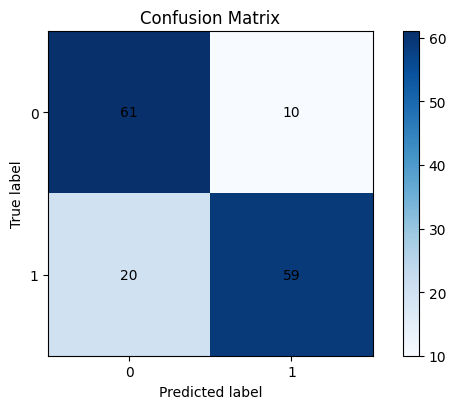

{'Accuracy': 0.8,
 'Precision': 0.855072463768116,
 'Recall': 0.7468354430379747,
 'F1-score': 0.7972972972972973}

In [75]:
# use evaluate_binary_classifier to evaluate the model on the test set
from model.metrics import evaluate_binary_classifier

y_pred = model.predict(X_test)
evaluate_binary_classifier(y_test, y_pred)